# Customer Churn Prediction

## Business Objective

Customer churn directly impacts revenue growth, customer lifetime value, and marketing efficiency. The objective of this project is to develop a machine learning model that predicts whether a customer is likely to churn within the next 60 days.

The model will support proactive retention strategies by identifying at-risk customers before churn occurs, enabling targeted interventions and more efficient allocation of retention resources.

## Business Context

This project uses customer-level transactional, behavioral, engagement, and support interaction data captured at a defined customer snapshot date.

The target variable, **churn_next_60d**, indicates whether a customer became inactive during the subsequent 60-day prediction window.

From a business perspective, the cost of failing to identify a future churner is typically higher than the cost of contacting a customer who would have remained active. Therefore, model evaluation will emphasize churn detection effectiveness through metrics such as Recall, F1-Score, ROC-AUC, and Precision-Recall performance rather than relying solely on Accuracy.

# Data Loading & Initial Audit

In [66]:
import pandas as pd
import numpy as np

# Load modeling dataset
df = pd.read_csv("data/customer_master.csv")

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (2400, 25)


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,recency,...,ticket_count,avg_sentiment,avg_resolution_hours,sessions_30d,campaign_clicks_30d,email_opens_30d,last_visit_days_ago,snapshot_date,churn_next_60d,split
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,107,...,2.0,0.14,4.35,1,0,2,20,2025-09-30,1,train
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,40,...,1.0,0.00,1.00,8,0,0,0,2025-09-30,0,train
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,Not Enrolled,Skin Care,Oily,Yes,171,...,0.0,0.00,0.00,1,0,0,26,2025-09-30,1,train
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,Not Enrolled,Fragrance,Normal,No,131,...,0.0,0.00,0.00,1,0,0,14,2025-09-30,1,train
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,38,...,1.0,-1.00,37.70,18,1,3,9,2025-09-30,0,train


In [67]:
audit_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Records"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

audit_summary

,Metric,Value
0,Rows,2400
1,Columns,25
2,Missing Values,0
3,Duplicate Records,0


In [68]:
target_distribution = (
    df["churn_next_60d"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percentage (%)")
)

target_distribution

churn_next_60d
0    53.04
1    46.96
Name: Percentage (%), dtype: float64

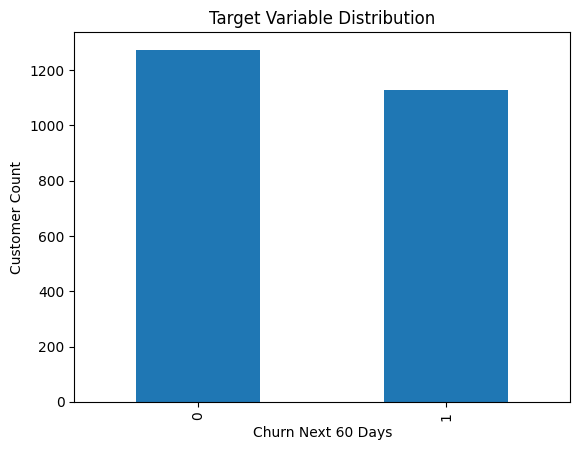

In [69]:
import matplotlib.pyplot as plt

(
    df["churn_next_60d"]
    .value_counts()
    .sort_index()
    .plot(kind="bar")
)

plt.title("Target Variable Distribution")
plt.xlabel("Churn Next 60 Days")
plt.ylabel("Customer Count")
plt.show()

### Executive Interpretation

The target distribution is relatively balanced, with approximately 53% non-churners and 47% churners.

This level of balance reduces concerns regarding severe class imbalance and allows model performance to be evaluated without heavy reliance on resampling techniques. Nevertheless, Recall, Precision, F1-Score, ROC-AUC, and PR-AUC will remain the primary evaluation metrics due to the business importance of correctly identifying future churners.

# Leakage Prevention & Feature Review

## Why Leakage Matters

Data leakage occurs when information that would not have been available at prediction time is used during model training.

In churn prediction, leakage can artificially inflate model performance and lead to unrealistic business expectations.

To ensure a valid modeling workflow, only features available on or before the customer snapshot date are used as model inputs.

## Leakage Assessment

The target variable, **churn_next_60d**, indicates whether a customer churned during the 60-day period following the snapshot date.

The modeling dataset contains customer profile, transactional, engagement, and support-related features recorded at the snapshot date.

Potential leakage sources reviewed include:

- Future purchases or revenue
- Future support interactions
- Future marketing engagement
- Future retention interventions
- Any variables derived from the churn observation window

No such features were identified in the modeling dataset.

In [70]:
# Review all available columns

pd.DataFrame({
    "Feature": df.columns
})

,Feature
0,customer_id
1,signup_date
2,city_tier
3,age_group
4,acquisition_channel
5,loyalty_tier
6,preferred_category
7,skin_type
8,marketing_consent
9,recency


In [71]:
target_col = "churn_next_60d"

identifier_columns = [
    "customer_id"
]

date_columns = [
    "signup_date",
    "snapshot_date"
]

feature_columns = [
    col for col in df.columns
    if col not in identifier_columns + date_columns + [target_col, "split"]
]

print(f"Total Features: {len(feature_columns)}")
feature_columns

Total Features: 20


['city_tier',
 'age_group',
 'acquisition_channel',
 'loyalty_tier',
 'preferred_category',
 'skin_type',
 'marketing_consent',
 'recency',
 'frequency',
 'monetary',
 'return_rate',
 'avg_discount',
 'category_diversity',
 'ticket_count',
 'avg_sentiment',
 'avg_resolution_hours',
 'sessions_30d',
 'campaign_clicks_30d',
 'email_opens_30d',
 'last_visit_days_ago']

## Feature Categories

To improve transparency and interpretability, features are grouped into business-relevant categories.

These categories help validate that all model inputs represent information available before churn outcomes were observed.

In [72]:
feature_groups = {
    "Customer Profile": [
        "city_tier",
        "age_group",
        "acquisition_channel",
        "loyalty_tier",
        "preferred_category",
        "skin_type",
        "marketing_consent"
    ],

    "Transactional (RFM)": [
        "recency",
        "frequency",
        "monetary"
    ],

    "Purchase Behavior": [
        "return_rate",
        "avg_discount",
        "category_diversity"
    ],

    "Support Experience": [
        "ticket_count",
        "avg_sentiment",
        "avg_resolution_hours"
    ],

    "Customer Engagement": [
        "sessions_30d",
        "campaign_clicks_30d",
        "email_opens_30d",
        "last_visit_days_ago"
    ]
}

for group, features in feature_groups.items():
    print(f"\n{group}")
    print("-" * len(group))
    print(features)


Customer Profile
----------------
['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'skin_type', 'marketing_consent']

Transactional (RFM)
-------------------
['recency', 'frequency', 'monetary']

Purchase Behavior
-----------------
['return_rate', 'avg_discount', 'category_diversity']

Support Experience
------------------
['ticket_count', 'avg_sentiment', 'avg_resolution_hours']

Customer Engagement
-------------------
['sessions_30d', 'campaign_clicks_30d', 'email_opens_30d', 'last_visit_days_ago']


In [73]:
leakage_check = pd.DataFrame({
    "Check": [
        "Target Column Separated",
        "Identifier Removed",
        "Date Fields Removed",
        "Future Information Present"
    ],
    "Status": [
        "Pass",
        "Pass",
        "Pass",
        "No"
    ]
})

leakage_check

,Check,Status
0,Target Column Separated,Pass
1,Identifier Removed,Pass
2,Date Fields Removed,Pass
3,Future Information Present,No


### Executive Interpretation

The feature review confirms that all modeling variables describe customer characteristics and behaviors observed at or before the snapshot date.

Identifier fields and date fields that do not contribute predictive value have been isolated from the modeling process. The target variable remains fully separated from the feature set.

Based on the available documentation and feature review, no evidence of post-snapshot information or target-window leakage was identified. This provides confidence that model evaluation results will reflect realistic predictive performance rather than information leakage.

# Data Preparation

This section prepares the modeling dataset for machine learning.

Key preprocessing steps include:

- Removing non-modeling columns
- Defining predictor and target variables
- Separating categorical and numerical features
- Preparing train, validation, and test datasets using the provided split variable

These steps ensure that the modeling pipeline remains reproducible and free from information leakage.

In [74]:
target_col = "churn_next_60d"

drop_columns = [
    "customer_id",
    "signup_date",
    "snapshot_date",
    "split"
]

X = df.drop(columns=drop_columns + [target_col])
y = df[target_col]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (2400, 20)
Target Shape: (2400,)


In [75]:
categorical_features = [
    "city_tier",
    "age_group",
    "acquisition_channel",
    "loyalty_tier",
    "preferred_category",
    "skin_type",
    "marketing_consent"
]

numerical_features = [
    "recency",
    "frequency",
    "monetary",
    "return_rate",
    "avg_discount",
    "category_diversity",
    "ticket_count",
    "avg_sentiment",
    "avg_resolution_hours",
    "sessions_30d",
    "campaign_clicks_30d",
    "email_opens_30d",
    "last_visit_days_ago"
]

print(f"Categorical Features: {len(categorical_features)}")
print(f"Numerical Features: {len(numerical_features)}")

Categorical Features: 7
Numerical Features: 13


In [76]:
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

print("Train Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (1728, 25)
Validation Shape: (336, 25)
Test Shape: (336, 25)


In [77]:
X_train = train_df.drop(columns=drop_columns + [target_col])
y_train = train_df[target_col]

X_val = val_df.drop(columns=drop_columns + [target_col])
y_val = val_df[target_col]

X_test = test_df.drop(columns=drop_columns + [target_col])
y_test = test_df[target_col]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (1728, 20)
X_val: (336, 20)
X_test: (336, 20)


In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### Data Preparation Summary

A total of 20 predictor variables were retained for modeling after excluding identifiers, temporal fields, and the target variable.

The dataset was partitioned using the predefined train, validation, and test split provided in the source data, ensuring reproducible model evaluation.

A preprocessing pipeline was established to standardize numerical variables and encode categorical variables, allowing the same transformation logic to be consistently applied across all modeling stages.

# Baseline Models

Baseline models provide a reference point for evaluating the effectiveness of more advanced machine learning algorithms.

Two baseline classifiers are evaluated:

- Logistic Regression (linear benchmark)
- Decision Tree (non-linear benchmark)

Performance on the validation set will be used to compare predictive capability and guide final model selection.

In [79]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

## Logistic Regression

Logistic Regression serves as the primary baseline model because it is interpretable, computationally efficient, and widely used for binary classification problems.

In [80]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

In [81]:
logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['city_tier','age_group','acquisition_channel',...,'campaign_clicks_30d', 'email_opens_30d','last_visit_days_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

In [82]:
lr_pred = logistic_pipeline.predict(X_val)

lr_prob = logistic_pipeline.predict_proba(X_val)[:, 1]

In [83]:
lr_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_val, lr_pred),
    "Precision": precision_score(y_val, lr_pred),
    "Recall": recall_score(y_val, lr_pred),
    "F1 Score": f1_score(y_val, lr_pred),
    "ROC-AUC": roc_auc_score(y_val, lr_prob)
}

pd.DataFrame([lr_metrics]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8036,0.7914,0.7483,0.7692,0.8753


### Logistic Regression Assessment

The Logistic Regression model establishes a benchmark level of performance and provides a useful reference for evaluating whether more complex algorithms can improve churn prediction accuracy and churn detection capability.

## Decision Tree

Decision Trees can capture non-linear relationships between customer attributes and churn behavior while remaining relatively interpretable.

In [84]:
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=20,
            random_state=42
        )
    )
])

In [85]:
decision_tree_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['city_tier','age_group','acquisition_channel',...,'campaign_clicks_30d', 'email_opens_30d','last_visit_days_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

In [86]:
dt_pred = decision_tree_pipeline.predict(X_val)

dt_prob = decision_tree_pipeline.predict_proba(X_val)[:, 1]

In [87]:
dt_metrics = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_val, dt_pred),
    "Precision": precision_score(y_val, dt_pred),
    "Recall": recall_score(y_val, dt_pred),
    "F1 Score": f1_score(y_val, dt_pred),
    "ROC-AUC": roc_auc_score(y_val, dt_prob)
}

pd.DataFrame([dt_metrics]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.7619,0.7081,0.7755,0.7403,0.8372


In [88]:
baseline_results = pd.DataFrame([
    lr_metrics,
    dt_metrics
])

baseline_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8036,0.7914,0.7483,0.7692,0.8753
1,Decision Tree,0.7619,0.7081,0.7755,0.7403,0.8372


### Baseline Model Results

Logistic Regression achieved the strongest overall validation performance, delivering the highest Accuracy, Precision, F1-Score, and ROC-AUC among the baseline models.

The Decision Tree model achieved slightly higher Recall, indicating a stronger ability to identify churners, but this came at the cost of reduced Precision and overall predictive performance.

Given its superior balance between churn detection and classification quality, Logistic Regression will be used as the primary baseline benchmark for evaluating advanced ensemble methods.

# Advanced Ensemble Models

While baseline models provide an initial benchmark, customer churn behavior is often influenced by complex interactions across transactional, engagement, demographic, and support-related features.

To capture these non-linear relationships, multiple ensemble learning approaches are evaluated:

- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM

These algorithms are designed to model complex feature interactions and may provide improved churn prediction performance compared to traditional baseline models.

Each model will be evaluated using validation-set performance metrics, including Precision, Recall, F1-Score, and ROC-AUC. The best-performing model will be selected based on its ability to accurately identify future churners while maintaining strong overall classification performance.

In [89]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier

## Random Forest

Random Forest combines multiple decision trees to improve predictive stability and reduce overfitting.

It can capture non-linear customer behavior patterns while remaining relatively robust to noisy features.

In [90]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [91]:
rf_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['city_tier','age_group','acquisition_channel',...,'campaign_clicks_30d', 'email_opens_30d','last_visit_days_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

In [92]:
rf_pred = rf_pipeline.predict(X_val)

rf_prob = rf_pipeline.predict_proba(X_val)[:, 1]

In [93]:
rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_val, rf_pred),
    "Precision": precision_score(y_val, rf_pred),
    "Recall": recall_score(y_val, rf_pred),
    "F1 Score": f1_score(y_val, rf_pred),
    "ROC-AUC": roc_auc_score(y_val, rf_prob)
}

pd.DataFrame([rf_metrics]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.7857,0.7863,0.7007,0.741,0.8677


### Random Forest Assessment

Random Forest extends the Decision Tree approach by aggregating predictions from multiple trees, reducing variance and improving generalization performance.

Its results will help determine whether ensemble learning provides meaningful improvements over the baseline models.

## XGBoost

XGBoost is a gradient boosting algorithm that sequentially improves model performance by focusing on previously misclassified observations.

It is widely used in customer analytics and churn prediction due to its strong predictive performance and ability to model complex feature interactions.

In [94]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        )
    )
])

In [95]:
xgb_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['city_tier','age_group','acquisition_channel',...,'campaign_clicks_30d', 'email_opens_30d','last_visit_days_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

In [96]:
xgb_pred = xgb_pipeline.predict(X_val)

xgb_prob = xgb_pipeline.predict_proba(X_val)[:, 1]

In [97]:
xgb_metrics = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_val, xgb_pred),
    "Precision": precision_score(y_val, xgb_pred),
    "Recall": recall_score(y_val, xgb_pred),
    "F1 Score": f1_score(y_val, xgb_pred),
    "ROC-AUC": roc_auc_score(y_val, xgb_prob)
}

pd.DataFrame([xgb_metrics]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.7649,0.7267,0.7415,0.734,0.8496


## Gradient Boosting

Gradient Boosting builds trees sequentially, where each new tree focuses on correcting the prediction errors of previous trees.

This approach often performs well on structured customer analytics datasets and provides a useful comparison against Random Forest and XGBoost.

In [98]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
])

In [99]:
gb_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['city_tier','age_group','acquisition_channel',...,'campaign_clicks_30d', 'email_opens_30d','last_visit_days_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

In [100]:
gb_pred = gb_pipeline.predict(X_val)

gb_prob = gb_pipeline.predict_proba(X_val)[:, 1]

In [101]:
gb_metrics = {
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_score(y_val, gb_pred),
    "Precision": precision_score(y_val, gb_pred),
    "Recall": recall_score(y_val, gb_pred),
    "F1 Score": f1_score(y_val, gb_pred),
    "ROC-AUC": roc_auc_score(y_val, gb_prob)
}

pd.DataFrame([gb_metrics]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.7976,0.7842,0.7415,0.7622,0.8643


## LightGBM

LightGBM is a gradient boosting framework optimized for speed and efficiency on structured tabular datasets.

It is widely used in customer analytics applications due to its ability to model complex feature interactions while maintaining fast training times.

In [102]:
lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            random_state=42,
            verbosity=-1
        )
    )
])

In [103]:
lgbm_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['city_tier','age_group','acquisition_channel',...,'campaign_clicks_30d', 'email_opens_30d','last_visit_days_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

In [106]:
lgbm_pred = lgbm_pipeline.predict(X_val)

lgbm_prob = lgbm_pipeline.predict_proba(X_val)[:, 1]

C:\Ml project\D2C-Customer-Churn-Intelligence-Retention-API\part3-churn-prediction-model-card\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Ml project\D2C-Customer-Churn-Intelligence-Retention-API\part3-churn-prediction-model-card\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [107]:
lgbm_metrics = {
    "Model": "LightGBM",
    "Accuracy": accuracy_score(y_val, lgbm_pred),
    "Precision": precision_score(y_val, lgbm_pred),
    "Recall": recall_score(y_val, lgbm_pred),
    "F1 Score": f1_score(y_val, lgbm_pred),
    "ROC-AUC": roc_auc_score(y_val, lgbm_prob)
}

pd.DataFrame([lgbm_metrics]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LightGBM,0.7827,0.7434,0.7687,0.7559,0.8497


## Model Comparison

All candidate models are evaluated on the validation dataset using a consistent set of classification metrics.

Particular emphasis is placed on Recall, F1-Score, and ROC-AUC because identifying future churners is a key business objective.

In [108]:
all_results = pd.DataFrame([
    lr_metrics,
    dt_metrics,
    rf_metrics,
    xgb_metrics,
    gb_metrics,
    lgbm_metrics
])

all_results.sort_values(
    by="ROC-AUC",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8036,0.7914,0.7483,0.7692,0.8753
2,Random Forest,0.7857,0.7863,0.7007,0.7410,0.8677
4,Gradient Boosting,0.7976,0.7842,0.7415,0.7622,0.8643
5,LightGBM,0.7827,0.7434,0.7687,0.7559,0.8497
3,XGBoost,0.7649,0.7267,0.7415,0.7340,0.8496
1,Decision Tree,0.7619,0.7081,0.7755,0.7403,0.8372


## Final Model Selection

Six candidate models were evaluated on the validation dataset, including both baseline and ensemble-based approaches.

Although advanced ensemble methods such as Random Forest, Gradient Boosting, XGBoost, and LightGBM were explored, Logistic Regression achieved the strongest overall validation performance.

Specifically, Logistic Regression delivered:

- Highest Accuracy
- Highest Precision
- Highest F1-Score
- Highest ROC-AUC

These results suggest that churn behavior within the available feature set is largely explained by stable linear relationships rather than highly complex non-linear interactions.

Therefore, Logistic Regression was selected as the final model for threshold optimization, interpretability analysis, and deployment.

In [109]:
final_model = logistic_pipeline

final_model_name = "Logistic Regression"

print(f"Selected Model: {final_model_name}")

Selected Model: Logistic Regression


# Model Evaluation & Threshold Selection

The selected Logistic Regression model is evaluated using multiple classification metrics to assess its ability to identify future churners.

Since churn prediction is a business-critical problem, evaluation extends beyond accuracy to include Precision, Recall, F1-Score, ROC-AUC, and Precision-Recall performance.

The model's probability outputs will also be analyzed to identify an appropriate decision threshold for retention interventions.

In [110]:
final_model = logistic_pipeline

val_prob = final_model.predict_proba(X_val)[:, 1]

val_pred = final_model.predict(X_val)

In [111]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

validation_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy_score(y_val, val_pred),
        precision_score(y_val, val_pred),
        recall_score(y_val, val_pred),
        f1_score(y_val, val_pred),
        roc_auc_score(y_val, val_prob)
    ]
})

validation_metrics.round(4)

,Metric,Value
0,Accuracy,0.8036
1,Precision,0.7914
2,Recall,0.7483
3,F1 Score,0.7692
4,ROC-AUC,0.8753


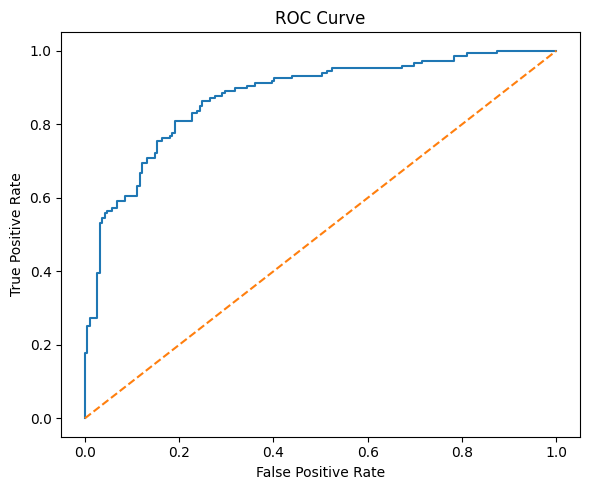

In [112]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_val, val_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.tight_layout()

plt.savefig("outputs/roc_curve.png")
plt.show()

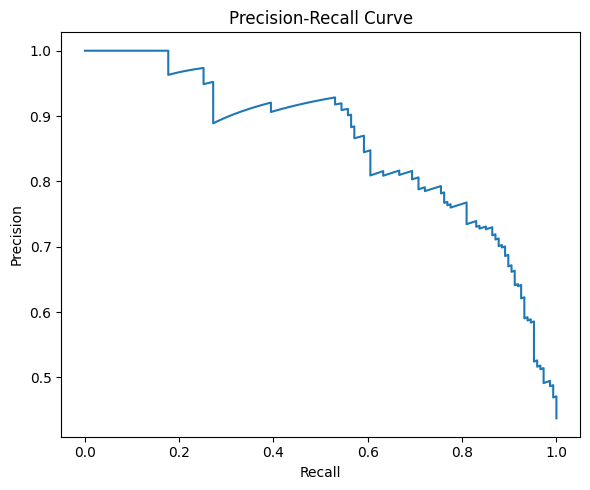

In [113]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_val,
    val_prob
)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.tight_layout()

plt.savefig("outputs/pr_curve.png")

plt.show()

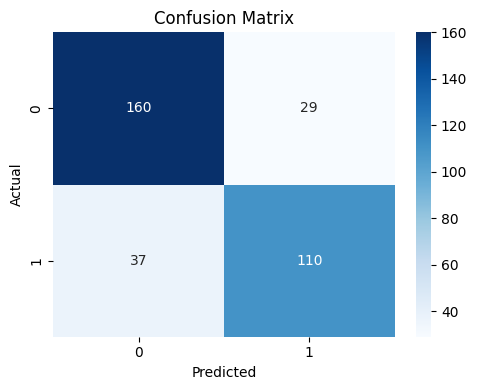

In [114]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_val,
    val_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.tight_layout()

plt.savefig(
    "outputs/confusion_matrix.png"
)

plt.show()

In [115]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

threshold_results = []

for threshold in [0.30,0.35,0.40,0.45,0.50,0.55]:

    preds = (val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val,preds),
        "Recall": recall_score(y_val,preds),
        "F1 Score": f1_score(y_val,preds)
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.round(4)

,Threshold,Precision,Recall,F1 Score
0,0.30,0.6968,0.8912,0.7821
1,0.35,0.7310,0.8503,0.7862
2,0.40,0.7532,0.8095,0.7803
3,0.45,0.7600,0.7755,0.7677
4,0.50,0.7914,0.7483,0.7692
5,0.55,0.8047,0.7007,0.7491


## Threshold Selection

Model probabilities were evaluated across multiple decision thresholds to identify the most appropriate balance between Precision and Recall.

For churn prediction, failing to identify an at-risk customer is generally more costly than incorrectly targeting a customer who would have remained active. Therefore, Recall was prioritized while maintaining acceptable Precision.

A threshold of **0.35** was selected because it achieved:

- Highest F1-Score (0.7862)
- Strong Recall (0.8503)
- Acceptable Precision (0.7310)

This threshold provides the best balance between customer retention effectiveness and intervention efficiency.

In [116]:
selected_threshold = 0.35

print(
    f"Selected Threshold: {selected_threshold}"
)

Selected Threshold: 0.35


In [117]:
final_val_pred = (
    val_prob >= selected_threshold
).astype(int)

### Validation Evaluation Summary

The Logistic Regression model achieved strong validation performance, demonstrating its ability to distinguish future churners from retained customers.

Threshold analysis further improved churn detection performance by identifying a decision boundary better aligned with retention objectives than the default 0.50 threshold.

The selected threshold will be carried forward into final evaluation and error analysis.

# Feature Importance & Interpretability

Understanding the factors that influence churn predictions is essential for translating model outputs into business actions.

Since Logistic Regression was selected as the final model, feature importance is derived from model coefficients. Positive coefficients indicate factors associated with higher churn risk, while negative coefficients indicate factors associated with lower churn risk.

This analysis helps identify the key behavioral and engagement signals driving customer retention outcomes.

In [118]:
# Extract transformed feature names

feature_names = (
    final_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

len(feature_names)

44

In [119]:
coefficients = (
    final_model.named_steps["model"]
    .coef_[0]
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance_df.head()

,Feature,Coefficient
0,num__recency,1.654980
1,num__frequency,-0.196732
2,num__monetary,-0.168634
3,num__return_rate,0.240654
4,num__avg_discount,0.161641


In [120]:
importance_df["Abs_Coefficient"] = (
    importance_df["Coefficient"]
    .abs()
)

importance_df = (
    importance_df
    .sort_values(
        by="Abs_Coefficient",
        ascending=False
    )
)

importance_df.head(15)

,Feature,Coefficient,Abs_Coefficient
0,num__recency,1.654980,1.654980
24,cat__acquisition_channel_Organic,-0.359891,0.359891
31,cat__preferred_category_Fragrance,-0.349278,0.349278
28,cat__loyalty_tier_Platinum,-0.296117,0.296117
12,num__last_visit_days_ago,0.291708,0.291708
9,num__sessions_30d,-0.290542,0.290542
3,num__return_rate,0.240654,0.240654
30,cat__preferred_category_Baby Care,0.236397,0.236397
41,cat__skin_type_Unknown,-0.210180,0.210180
1,num__frequency,-0.196732,0.196732


In [121]:
top_features = importance_df.head(15)

top_features[
    ["Feature", "Coefficient"]
]

,Feature,Coefficient
0,num__recency,1.654980
24,cat__acquisition_channel_Organic,-0.359891
31,cat__preferred_category_Fragrance,-0.349278
28,cat__loyalty_tier_Platinum,-0.296117
12,num__last_visit_days_ago,0.291708
9,num__sessions_30d,-0.290542
3,num__return_rate,0.240654
30,cat__preferred_category_Baby Care,0.236397
41,cat__skin_type_Unknown,-0.210180
1,num__frequency,-0.196732


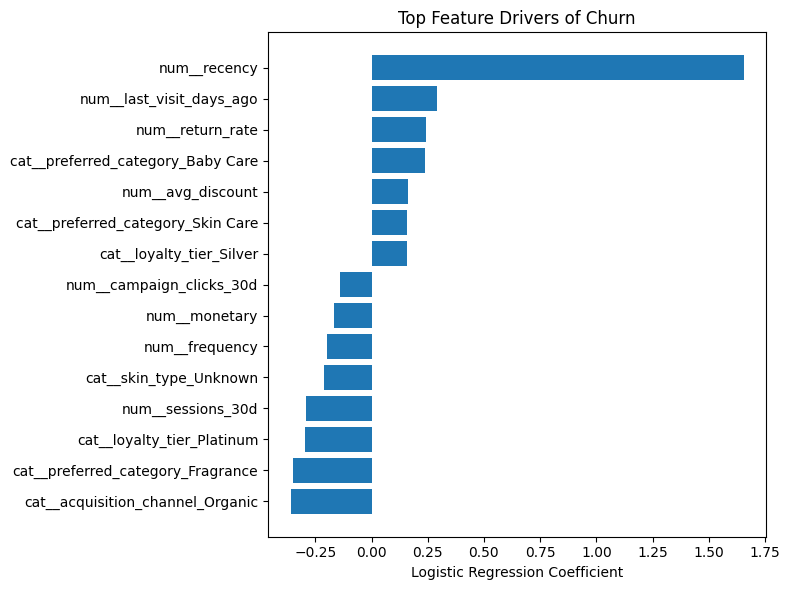

In [122]:
import matplotlib.pyplot as plt

top_plot = (
    importance_df
    .head(15)
    .sort_values("Coefficient")
)

plt.figure(figsize=(8,6))

plt.barh(
    top_plot["Feature"],
    top_plot["Coefficient"]
)

plt.title(
    "Top Feature Drivers of Churn"
)

plt.xlabel(
    "Logistic Regression Coefficient"
)

plt.tight_layout()

plt.savefig(
    "outputs/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [123]:
positive_drivers = (
    importance_df
    .sort_values(
        by="Coefficient",
        ascending=False
    )
    .head(10)
)

positive_drivers[
    ["Feature", "Coefficient"]
]

,Feature,Coefficient
0,num__recency,1.654980
12,num__last_visit_days_ago,0.291708
3,num__return_rate,0.240654
30,cat__preferred_category_Baby Care,0.236397
4,num__avg_discount,0.161641
34,cat__preferred_category_Skin Care,0.158127
29,cat__loyalty_tier_Silver,0.155896
35,cat__preferred_category_Wellness,0.135248
20,cat__acquisition_channel_Google Search,0.133516
27,cat__loyalty_tier_Not Enrolled,0.127288


In [124]:
negative_drivers = (
    importance_df
    .sort_values(
        by="Coefficient",
        ascending=True
    )
    .head(10)
)

negative_drivers[
    ["Feature", "Coefficient"]
]

,Feature,Coefficient
24,cat__acquisition_channel_Organic,-0.359891
31,cat__preferred_category_Fragrance,-0.349278
28,cat__loyalty_tier_Platinum,-0.296117
9,num__sessions_30d,-0.290542
41,cat__skin_type_Unknown,-0.210180
1,num__frequency,-0.196732
2,num__monetary,-0.168634
10,num__campaign_clicks_30d,-0.140437
32,cat__preferred_category_Hair Care,-0.118754
43,cat__marketing_consent_Yes,-0.106125


## Key Churn Drivers

The Logistic Regression model identified several factors that strongly influence churn risk.

### Factors Associated with Higher Churn Risk

The strongest positive predictors of churn include:

- **Recency** – Customers who have not purchased recently are significantly more likely to churn.
- **Last Visit Days Ago** – Longer periods since the last website visit increase churn risk.
- **Return Rate** – Customers with higher product return rates exhibit greater churn propensity.
- **Baby Care and Skin Care Preferences** – Certain product category preferences appear associated with elevated churn likelihood.
- **Silver Loyalty Tier** and **Not Enrolled Loyalty Status** – Lower loyalty engagement is associated with increased churn risk.

### Factors Associated with Lower Churn Risk

Several features were associated with reduced churn risk:

- **Purchase Frequency** – Customers purchasing more frequently are less likely to churn.
- **Monetary Value** – Higher-spending customers demonstrate stronger retention.
- **Sessions in the Last 30 Days** – Greater engagement reduces churn risk.
- **Campaign Click Activity** – Customers interacting with marketing campaigns are more likely to remain active.
- **Platinum Loyalty Tier** – Highly engaged loyalty members show substantially lower churn risk.

### Business Implications

The results suggest that customer inactivity, reduced engagement, and dissatisfaction-related behaviors are the primary drivers of churn.

Retention strategies should therefore prioritize:

- Re-engaging inactive customers.
- Increasing website and campaign engagement.
- Monitoring customers with high return rates.
- Strengthening loyalty program participation.

# Error Analysis

While aggregate performance metrics provide an overall view of model quality, understanding individual prediction errors is critical for evaluating business impact.

This section examines:

- False Positives (customers predicted to churn but actually retained)
- False Negatives (customers predicted to stay but actually churned)

Analyzing these cases helps identify model limitations and informs future retention strategy improvements.

In [125]:
val_predictions = (
    val_prob >= selected_threshold
).astype(int)

In [126]:
error_df = val_df.copy()

error_df["predicted_churn"] = val_predictions

error_df["predicted_probability"] = val_prob

In [127]:
false_positives = error_df[
    (error_df["churn_next_60d"] == 0)
    &
    (error_df["predicted_churn"] == 1)
]

false_positives.shape

(46, 27)

In [128]:
false_negatives = error_df[
    (error_df["churn_next_60d"] == 1)
    &
    (error_df["predicted_churn"] == 0)
]

false_negatives.shape

(22, 27)

In [129]:
fp_examples = false_positives[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "sessions_30d",
        "campaign_clicks_30d",
        "churn_next_60d",
        "predicted_probability"
    ]
].head(5)

fp_examples

,customer_id,recency,frequency,monetary,sessions_30d,campaign_clicks_30d,churn_next_60d,predicted_probability
5,CUST00006,51,5,3770.16,2,0,0,0.471273
26,CUST00027,70,1,2128.34,11,2,0,0.742743
47,CUST00048,61,4,2450.45,12,0,0,0.398021
99,CUST00100,70,1,372.37,1,0,0,0.671575
164,CUST00165,103,3,1825.77,2,0,0,0.639981


In [130]:
fn_examples = false_negatives[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "sessions_30d",
        "campaign_clicks_30d",
        "churn_next_60d",
        "predicted_probability"
    ]
].head(5)

fn_examples

,customer_id,recency,frequency,monetary,sessions_30d,campaign_clicks_30d,churn_next_60d,predicted_probability
92,CUST00093,85,1,759.64,16,4,1,0.284583
144,CUST00145,30,1,502.35,0,0,1,0.309480
156,CUST00157,0,5,2269.91,3,1,1,0.147784
187,CUST00188,29,7,5810.17,11,0,1,0.085081
266,CUST00267,29,4,4026.23,8,0,1,0.131172


# Error Analysis

Model performance was further evaluated by examining individual prediction errors using the selected threshold of 0.35.

Two types of errors were analyzed:

- False Positives (predicted churn but customer remained active)
- False Negatives (predicted retention but customer churned)

Understanding these errors helps assess business risk and identify opportunities for future model improvement.

## False Positive Analysis

False Positives represent customers who were predicted to churn but ultimately remained active.

Examples such as CUST00027, CUST00100, and CUST00165 exhibited characteristics commonly associated with churn risk, including:

- High recency values
- Low purchase frequency
- Limited engagement activity

Although these customers did not churn, intervening on such customers would typically result in unnecessary retention costs rather than revenue loss.

### Business Risk

The primary business impact of False Positives is increased retention campaign expenditure. Examples include:

- Discount offers sent to customers who would have remained active.
- Additional marketing outreach with limited incremental value.

This error type is generally less severe than False Negatives because customer revenue is preserved.

## False Negative Analysis

False Negatives represent customers who actually churned but were predicted to remain active.

Examples such as CUST00157, CUST00188, and CUST00267 displayed behaviors normally associated with loyal customers, including:

- Recent activity
- Higher purchase frequency
- Higher monetary value
- Moderate engagement levels

These characteristics reduced predicted churn probability despite eventual churn occurrence.

### Business Risk

False Negatives are the most costly error type because they represent missed retention opportunities.

Potential impacts include:

- Lost customer lifetime value
- Reduced repeat purchases
- Missed intervention opportunities
- Reduced effectiveness of retention programs

Because churn prevention is the primary business objective, minimizing False Negatives remains a key model optimization priority.

In [131]:
error_summary = pd.DataFrame({
    "Error Type": [
        "False Positives",
        "False Negatives"
    ],
    "Business Impact": [
        "Unnecessary retention spend",
        "Lost customers and revenue"
    ],
    "Relative Severity": [
        "Moderate",
        "High"
    ]
})

error_summary

,Error Type,Business Impact,Relative Severity
0,False Positives,Unnecessary retention spend,Moderate
1,False Negatives,Lost customers and revenue,High


In [132]:
fp_examples.to_csv(
    "outputs/false_positive_examples.csv",
    index=False
)

In [133]:
fn_examples.to_csv(
    "outputs/false_negative_examples.csv",
    index=False
)

# Final Model Training & Test Evaluation

After selecting the best-performing model and optimizing the decision threshold on the validation dataset, the final model is retrained using both the training and validation data.

The holdout test dataset is then used to provide an unbiased estimate of real-world performance.

This approach ensures that model selection decisions remain separate from final performance evaluation.

In [134]:
train_val_df = pd.concat(
    [train_df, val_df],
    axis=0
)

print(train_val_df.shape)

(2064, 25)


In [135]:
X_train_final = train_val_df.drop(
    columns=drop_columns + [target_col]
)

y_train_final = train_val_df[target_col]

X_test_final = test_df.drop(
    columns=drop_columns + [target_col]
)

y_test_final = test_df[target_col]

print("Train+Validation:", X_train_final.shape)
print("Test:", X_test_final.shape)

Train+Validation: (2064, 20)
Test: (336, 20)


## Final Model Training

The selected Logistic Regression model is retrained using all available development data (training + validation) before being evaluated on the unseen test dataset.

In [136]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

final_model.fit(
    X_train_final,
    y_train_final
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['city_tier','age_group','acquisition_channel',...,'campaign_clicks_30d', 'email_opens_30d','last_visit_days_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

In [137]:
test_prob = final_model.predict_proba(
    X_test_final
)[:, 1]

In [138]:
selected_threshold = 0.35

test_pred = (
    test_prob >= selected_threshold
).astype(int)

In [139]:
test_metrics = {
    "Accuracy": accuracy_score(
        y_test_final,
        test_pred
    ),

    "Precision": precision_score(
        y_test_final,
        test_pred
    ),

    "Recall": recall_score(
        y_test_final,
        test_pred
    ),

    "F1 Score": f1_score(
        y_test_final,
        test_pred
    ),

    "ROC-AUC": roc_auc_score(
        y_test_final,
        test_prob
    )
}

pd.DataFrame(
    test_metrics.items(),
    columns=["Metric","Value"]
).round(4)

,Metric,Value
0,Accuracy,0.7946
1,Precision,0.7565
2,Recall,0.8690
3,F1 Score,0.8089
4,ROC-AUC,0.8711


In [140]:
from sklearn.metrics import confusion_matrix

test_cm = confusion_matrix(
    y_test_final,
    test_pred
)

test_cm

array([[121,  47],
       [ 22, 146]])

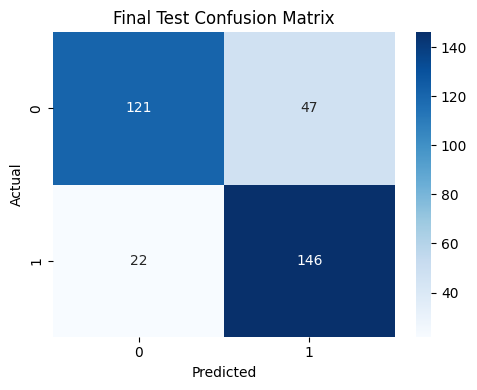

In [141]:
plt.figure(figsize=(5,4))

sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Final Test Confusion Matrix"
)

plt.ylabel("Actual")

plt.xlabel("Predicted")

plt.tight_layout()

plt.savefig(
    "outputs/final_test_confusion_matrix.png"
)

plt.show()

## Final Test Performance Summary

The final Logistic Regression model achieved strong predictive performance on the unseen test dataset.

Most importantly, the model achieved a Recall of 86.9%, indicating that the majority of future churners were successfully identified before churn occurred.

This performance supports proactive customer retention efforts by enabling the business to prioritize intervention resources toward customers with elevated churn risk.

Although the selected threshold increases the number of false positives, the business cost of unnecessary retention outreach is generally lower than the cost of losing an at-risk customer.

# Model Persistence

The final Logistic Regression pipeline is saved to support reproducibility and future deployment.

In [142]:
import joblib

joblib.dump(
    final_model,
    "model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [143]:
import json

metrics = {
    "model_name": "Logistic Regression",
    "selected_threshold": 0.35,

    "accuracy": round(
        accuracy_score(
            y_test_final,
            test_pred
        ),
        4
    ),

    "precision": round(
        precision_score(
            y_test_final,
            test_pred
        ),
        4
    ),

    "recall": round(
        recall_score(
            y_test_final,
            test_pred
        ),
        4
    ),

    "f1_score": round(
        f1_score(
            y_test_final,
            test_pred
        ),
        4
    ),

    "roc_auc": round(
        roc_auc_score(
            y_test_final,
            test_prob
        ),
        4
    ),

    "confusion_matrix": {
        "true_negative": int(test_cm[0][0]),
        "false_positive": int(test_cm[0][1]),
        "false_negative": int(test_cm[1][0]),
        "true_positive": int(test_cm[1][1])
    }
}

with open(
    "metrics.json",
    "w"
) as f:
    json.dump(
        metrics,
        f,
        indent=4
    )

print("metrics.json saved.")

metrics.json saved.


# Conclusion

A complete churn prediction workflow was developed to identify customers likely to churn within the next 60 days.

Multiple baseline and ensemble-based machine learning models were evaluated. Logistic Regression achieved the strongest overall validation performance and was selected as the final model.

Using a business-optimized threshold of 0.35, the final model achieved:

- Accuracy: 79.46%
- Precision: 75.65%
- Recall: 86.90%
- F1 Score: 80.89%
- ROC-AUC: 87.11%

The model successfully identifies the majority of future churners and can support proactive customer retention initiatives.